### ライブラリのインポート

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

### データ読み込み
学習データとテストデータを読み込む

In [44]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
dataset = pd.read_csv("data/dataset.csv")
labels = dataset.set_index("Id")["Merged"]

In [45]:
print(train.shape)
print(test.shape)

(240, 15)
(60, 14)


### 学習データの最初の5件を表示

In [46]:
train.head()

,Id,Merged,TitleLength,BodyLength,Additions,Deletions,ChangedFiles,Commits,Draft,Labels,IsBot,IssueComments,ReviewComments,CreatedHour,CreatedDay
0,4841,0,64,329,15777,4,7,3,0,0,0,0,0,17,monday
1,4843,1,56,101,2,2,2,1,0,0,0,2,0,19,monday
2,4846,0,49,149,69,1,5,3,0,0,0,1,0,21,monday
3,4847,1,60,754,114,9,2,3,0,0,0,5,0,21,monday
4,4848,1,64,275,58,0,2,1,0,0,0,6,0,0,tuesday


### データ型のチェック

In [47]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Id              240 non-null    int64
 1   Merged          240 non-null    int64
 2   TitleLength     240 non-null    int64
 3   BodyLength      240 non-null    int64
 4   Additions       240 non-null    int64
 5   Deletions       240 non-null    int64
 6   ChangedFiles    240 non-null    int64
 7   Commits         240 non-null    int64
 8   Draft           240 non-null    int64
 9   Labels          240 non-null    int64
 10  IsBot           240 non-null    int64
 11  IssueComments   240 non-null    int64
 12  ReviewComments  240 non-null    int64
 13  CreatedHour     240 non-null    int64
 14  CreatedDay      240 non-null    str  
dtypes: int64(14), str(1)
memory usage: 28.3 KB


### テストデータの最初の5件を表示

In [48]:
test.head()

,Id,TitleLength,BodyLength,Additions,Deletions,ChangedFiles,Commits,Draft,Labels,IsBot,IssueComments,ReviewComments,CreatedHour,CreatedDay
0,5173,77,1422,11,2,1,1,0,0,0,2,0,18,thursday
1,5174,57,1532,3,1,1,1,0,0,0,2,0,18,thursday
2,5175,47,1520,3,4,1,1,0,0,0,2,0,18,thursday
3,5176,54,1844,1,2,1,1,0,0,0,2,0,18,thursday
4,5178,64,1243,16,0,2,1,0,0,0,1,0,4,friday


In [49]:
train.isnull().sum()

Id                0
Merged            0
TitleLength       0
BodyLength        0
Additions         0
Deletions         0
ChangedFiles      0
Commits           0
Draft             0
Labels            0
IsBot             0
IssueComments     0
ReviewComments    0
CreatedHour       0
CreatedDay        0
dtype: int64

In [50]:
test.isnull().sum()

Id                0
TitleLength       0
BodyLength        0
Additions         0
Deletions         0
ChangedFiles      0
Commits           0
Draft             0
Labels            0
IsBot             0
IssueComments     0
ReviewComments    0
CreatedHour       0
CreatedDay        0
dtype: int64

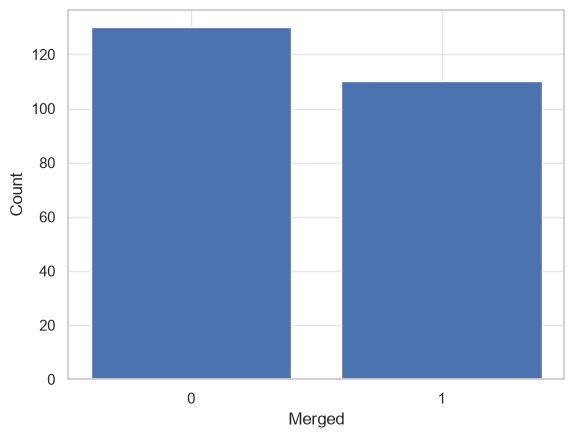

In [51]:
merged_counts = train["Merged"].value_counts().sort_index()
plt.bar(merged_counts.index.astype(str), merged_counts)
plt.xlabel("Merged")
plt.ylabel("Count")
plt.show()

In [52]:
print(train["Merged"].value_counts(normalize=True).sort_index() * 100)

Merged
0    54.166667
1    45.833333
Name: proportion, dtype: float64


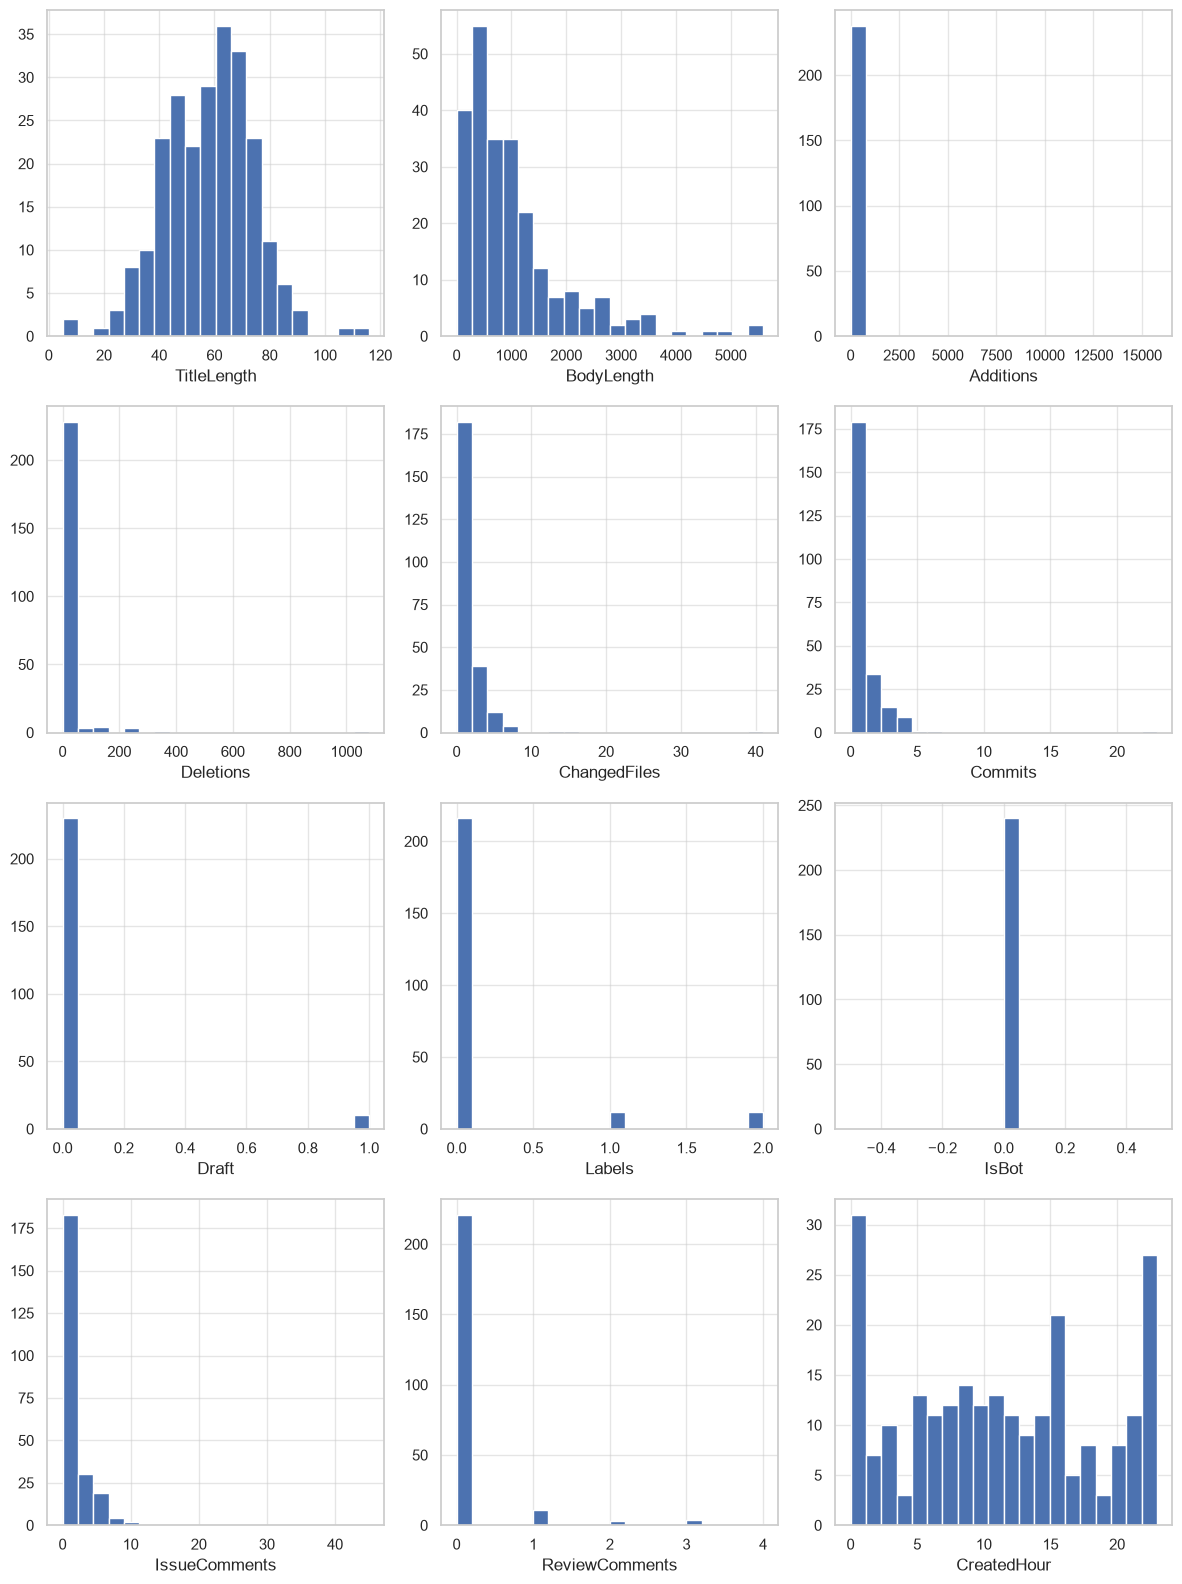

In [53]:
numeric_cols = []
for col in train.columns:
    if col == "Id" or col == "Merged":
        continue
    if train[col].dtype == "int64" or train[col].dtype == "float64":
        numeric_cols.append(col)

n = len(numeric_cols)
rows = n // 3
if n % 3 != 0:
    rows = rows + 1

plt.figure(figsize=(12, 4 * rows))
i = 1
for col in numeric_cols:
    plt.subplot(rows, 3, i)
    plt.hist(train[col].dropna(), bins=20)
    plt.xlabel(col)
    i = i + 1
plt.tight_layout()
plt.show()


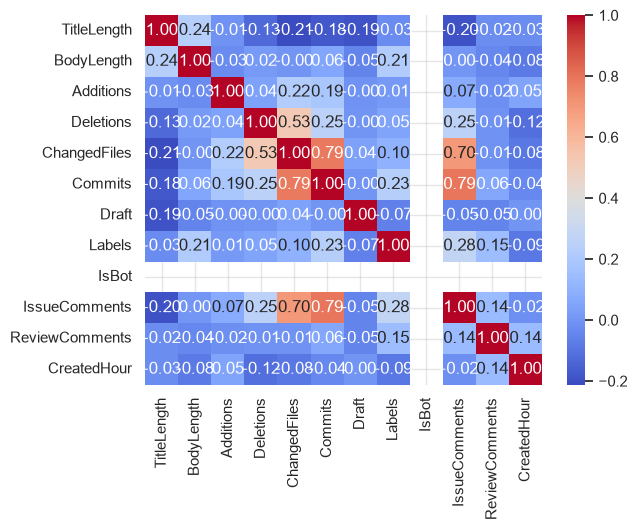

In [54]:
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()


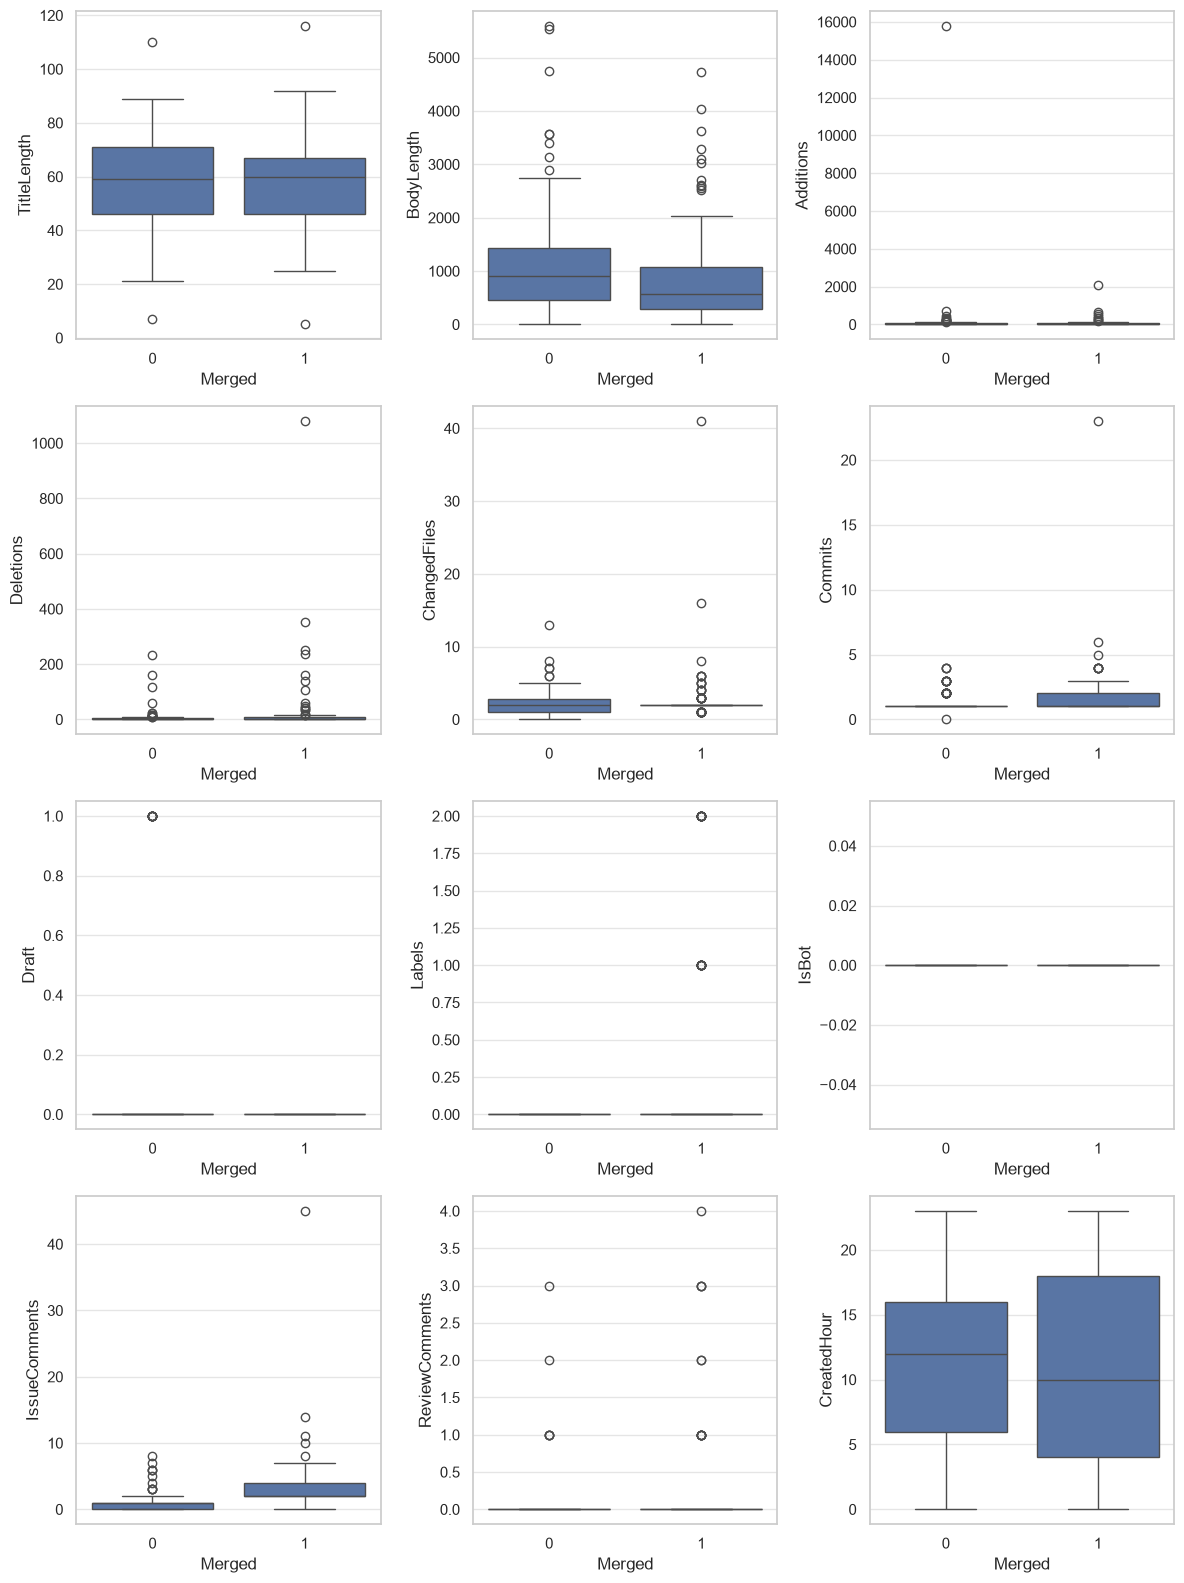

In [55]:
plt.figure(figsize=(12, 4 * rows))
i = 1
for col in numeric_cols:
    plt.subplot(rows, 3, i)
    sns.boxplot(data=train, x="Merged", y=col)
    i = i + 1
plt.tight_layout()
plt.show()


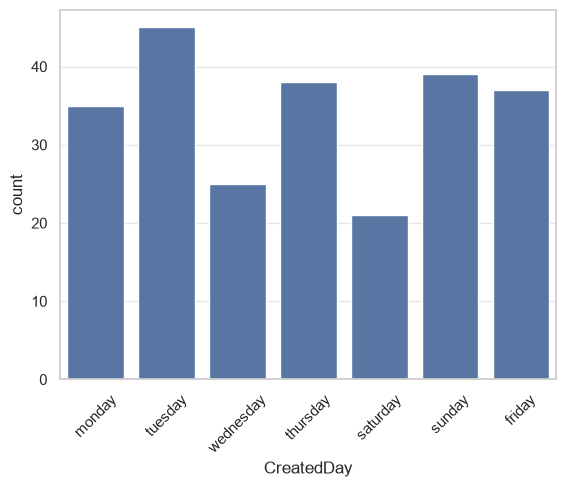

In [56]:
sns.countplot(data=train, x="CreatedDay")
plt.xticks(rotation=45)
plt.show()


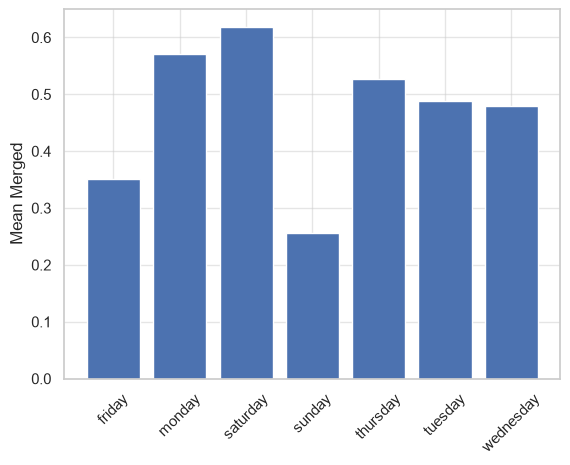

In [57]:
means = train.groupby("CreatedDay")["Merged"].mean()
plt.bar(means.index, means)
plt.xticks(rotation=45)
plt.ylabel("Mean Merged")
plt.show()

In [58]:
ids_test = test["Id"]
y_train = train["Merged"]
x_train = train.drop(columns=["Id", "Merged"])
x_test = test.drop(columns=["Id"])
x_train = x_train.fillna(0)
x_test = x_test.fillna(0)

In [59]:
x_train.isnull().sum()

TitleLength       0
BodyLength        0
Additions         0
Deletions         0
ChangedFiles      0
Commits           0
Draft             0
Labels            0
IsBot             0
IssueComments     0
ReviewComments    0
CreatedHour       0
CreatedDay        0
dtype: int64

In [60]:
x_test.isnull().sum()

TitleLength       0
BodyLength        0
Additions         0
Deletions         0
ChangedFiles      0
Commits           0
Draft             0
Labels            0
IsBot             0
IssueComments     0
ReviewComments    0
CreatedHour       0
CreatedDay        0
dtype: int64

In [61]:
x_train = pd.get_dummies(x_train, columns=["CreatedDay"])
x_test = pd.get_dummies(x_test, columns=["CreatedDay"])
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)
x_train.head()

,TitleLength,BodyLength,Additions,Deletions,ChangedFiles,Commits,Draft,Labels,IsBot,IssueComments,ReviewComments,CreatedHour,CreatedDay_friday,CreatedDay_monday,CreatedDay_saturday,CreatedDay_sunday,CreatedDay_thursday,CreatedDay_tuesday,CreatedDay_wednesday
0,64,329,15777,4,7,3,0,0,0,0,0,17,False,True,False,False,False,False,False
1,56,101,2,2,2,1,0,0,0,2,0,19,False,True,False,False,False,False,False
2,49,149,69,1,5,3,0,0,0,1,0,21,False,True,False,False,False,False,False
3,60,754,114,9,2,3,0,0,0,5,0,21,False,True,False,False,False,False,False
4,64,275,58,0,2,1,0,0,0,6,0,0,False,False,False,False,False,True,False


### RandomForest・Logistic回帰・LightGBMをOptunaでチューニングしてスコアを出力
学習データは CreatedAt 昇順（古い→新しい）なので、TimeSeriesSplit で「過去で学習・未来で検証」する。テストデータは最終評価にだけ使う。

In [62]:
y_true = labels.reindex(list(ids_test))
cv = TimeSeriesSplit(n_splits=5)
n_trials = 30


def cv_accuracy(model):
    return cross_val_score(model, x_train, y_train, cv=cv, scoring="accuracy").mean()


def tune(objective):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(objective, n_trials=n_trials)
    return study


def rf_objective(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=42,
    )
    return cv_accuracy(model)


def lr_objective(trial):
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=trial.suggest_float("C", 1e-3, 10.0, log=True),
                    class_weight=trial.suggest_categorical(
                        "class_weight", [None, "balanced"]
                    ),
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    )
    return cv_accuracy(model)


def lgbm_objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 6)
    model = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=max_depth,
        num_leaves=trial.suggest_int("num_leaves", 4, min(31, 2**max_depth)),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 20),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=42,
        verbosity=-1,
    )
    return cv_accuracy(model)


rf_study = tune(rf_objective)
rf = RandomForestClassifier(**rf_study.best_params, random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print("Random Forest")
print("best params:", rf_study.best_params)
print("cv accuracy:", rf_study.best_value)
print(classification_report(y_true, rf_pred, digits=3))
print("accuracy:", accuracy_score(y_true, rf_pred))

lr_study = tune(lr_objective)
lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                **lr_study.best_params,
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

print("Logistic Regression")
print("best params:", lr_study.best_params)
print("cv accuracy:", lr_study.best_value)
print(classification_report(y_true, lr_pred, digits=3))
print("accuracy:", accuracy_score(y_true, lr_pred))

lgbm_study = tune(lgbm_objective)
lgbm = LGBMClassifier(**lgbm_study.best_params, random_state=42, verbosity=-1)
lgbm.fit(x_train, y_train)
lgbm_pred = lgbm.predict(x_test)

print("LightGBM")
print("best params:", lgbm_study.best_params)
print("cv accuracy:", lgbm_study.best_value)
print(classification_report(y_true, lgbm_pred, digits=3))
print("accuracy:", accuracy_score(y_true, lgbm_pred))

scores = pd.DataFrame(
    {
        "model": ["Random Forest", "Logistic Regression", "LightGBM"],
        "cv_accuracy": [
            rf_study.best_value,
            lr_study.best_value,
            lgbm_study.best_value,
        ],
        "test_accuracy": [
            accuracy_score(y_true, rf_pred),
            accuracy_score(y_true, lr_pred),
            accuracy_score(y_true, lgbm_pred),
        ],
    }
)
print(scores.to_string(index=False))
pd.DataFrame(
    {
        "Id": ids_test,
        "Merged_rf": rf_pred,
        "Merged_lr": lr_pred,
        "Merged_lgbm": lgbm_pred,
    }
)

Random Forest
best params: {'n_estimators': 271, 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None}
cv accuracy: 0.795
              precision    recall  f1-score   support

           0      0.917     0.786     0.846        28
           1      0.833     0.938     0.882        32

    accuracy                          0.867        60
   macro avg      0.875     0.862     0.864        60
weighted avg      0.872     0.867     0.865        60

accuracy: 0.8666666666666667
Logistic Regression
best params: {'C': 1.848040926237072, 'class_weight': 'balanced'}
cv accuracy: 0.75
              precision    recall  f1-score   support

           0      0.697     0.821     0.754        28
           1      0.815     0.688     0.746        32

    accuracy                          0.750        60
   macro avg      0.756     0.754     0.750        60
weighted avg      0.760     0.750     0.750        60

accuracy: 0.75
LightGBM
best params: {'max_depth': 5, 'n_est

,Id,Merged_rf,Merged_lr,Merged_lgbm
0,5173,1,0,0
1,5174,1,0,1
2,5175,1,0,0
3,5176,1,0,0
4,5178,0,0,0
5,5179,1,1,1
6,5180,0,0,0
7,5182,1,1,1
8,5183,1,1,1
9,5184,1,1,1


### 重要度をグラフ化

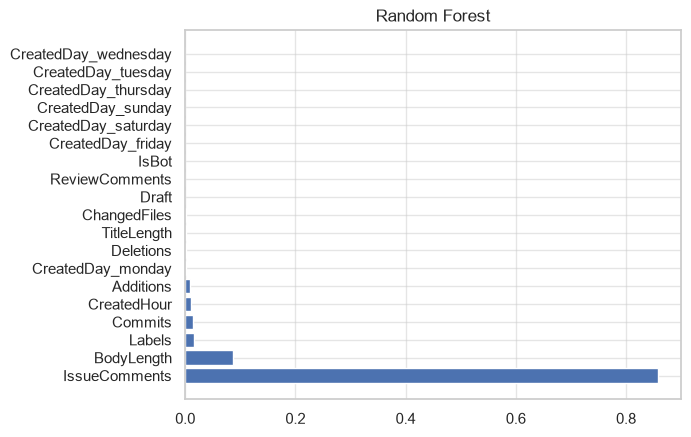

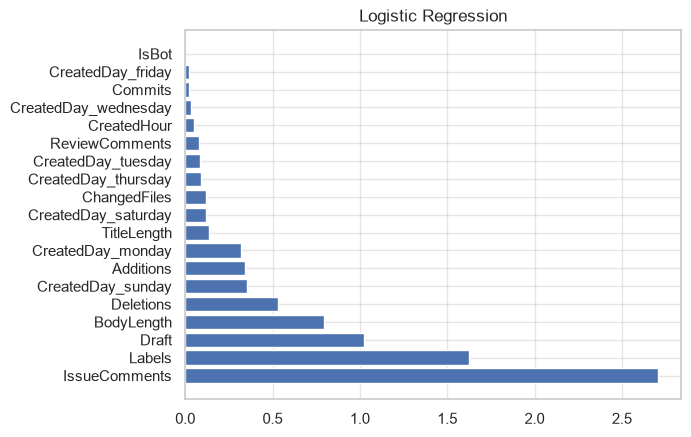

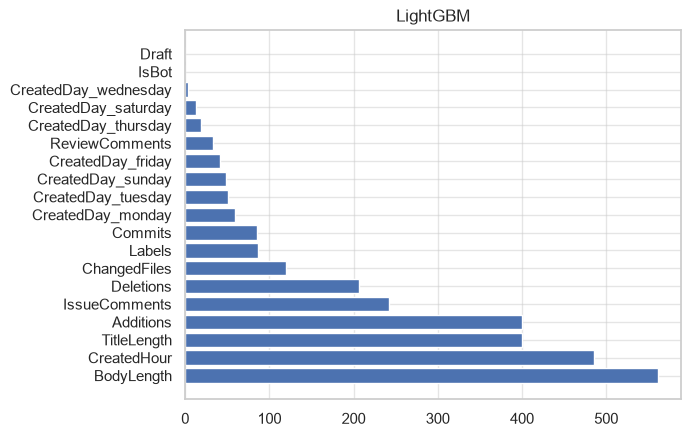

In [63]:
rf_imp = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_,
})
rf_imp = rf_imp.sort_values("Importance", ascending=False)
plt.barh(rf_imp["Feature"], rf_imp["Importance"])
plt.title("Random Forest")
plt.show()

lr_imp = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": abs(lr.named_steps["clf"].coef_[0]),
})
lr_imp = lr_imp.sort_values("Importance", ascending=False)
plt.barh(lr_imp["Feature"], lr_imp["Importance"])
plt.title("Logistic Regression")
plt.show()

lgbm_imp = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": lgbm.feature_importances_,
})
lgbm_imp = lgbm_imp.sort_values("Importance", ascending=False)
plt.barh(lgbm_imp["Feature"], lgbm_imp["Importance"])
plt.title("LightGBM")
plt.show()